# NLP Lab — Text Preprocessing and N-gram Analysis
**Course:** Natural Language Processing (Lab) &nbsp;|&nbsp; **Course Code:** CSET346 &nbsp;|&nbsp; **Semester:** ODD 2026-27

This notebook covers all four questions of the lab sheet:
1. **Q1** — Sentence/word tokenization and stop-word removal on the Brown Corpus.
2. **Q2** — Stemming vs. Lemmatization comparison on Brown Corpus words.
3. **Q3** — Basic spelling correction using the NLTK Words Corpus and edit distance.
4. **Q4** — Unigram, bigram, and trigram frequency analysis on the Brown Corpus.

This notebook has been fully executed end-to-end (Run All) with all outputs saved — see the outputs below each cell.

## Setup — Install and Import Libraries, Download NLTK Resources

In [1]:
# Install/import required libraries
import re
import string
from collections import defaultdict, Counter

import pandas as pd

import nltk
from nltk.corpus import brown, stopwords, words as words_corpus
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.util import ngrams
from nltk.probability import FreqDist
from nltk.metrics.distance import edit_distance

# Download all required NLTK resources
nltk.download("brown", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("words", quiet=True)

print("Setup complete — all NLTK resources downloaded.")

Setup complete — all NLTK resources downloaded.


---
## Q1 — Tokenization and Stop-Word Removal

**Task:** Load the Brown Corpus, select at least 20 sentences, perform sentence and word tokenization,
lowercase the tokens, remove punctuation and stop words, and display before/after for 5 sentences.

In [2]:
# (a) Load the Brown Corpus and select at least 20 sentences
# brown.sents() returns already word-tokenized sentences with POS tags stripped.
brown_sents = brown.sents(categories="news")[:20]
print("Number of sentences selected from Brown Corpus:", len(brown_sents))

# Reconstruct plain-text sentences from the token lists (fixes spacing before punctuation)
def detokenize(tokens):
    text = " ".join(tokens)
    text = re.sub(r"\s+([.,!?;:'\"])", r"\1", text)
    return text

original_sentences = [detokenize(s) for s in brown_sents]
for i, s in enumerate(original_sentences[:5], 1):
    print(f"{i}. {s}")

Number of sentences selected from Brown Corpus: 20
1. The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence'' that any irregularities took place.
2. The jury further said in term-end presentments that the City Executive Committee, which had over-all charge of the election, `` deserves the praise and thanks of the City of Atlanta'' for the manner in which the election was conducted.
3. The September-October term jury had been charged by Fulton Superior Court Judge Durwood Pye to investigate reports of possible `` irregularities'' in the hard-fought primary which was won by Mayor-nominate Ivan Allen Jr..
4. `` Only a relative handful of such reports was received'', the jury said, `` considering the widespread interest in the election, the number of voters and the size of this city''.
5. The jury said it did find that many of Georgia's registration and election laws `` are outmoded or inadequate and often ambiguous''.


In [3]:
# (b) Perform sentence-level tokenization
# Join the selected sentences into one paragraph and re-split it using NLTK's
# sentence tokenizer, to demonstrate sent_tokenize() explicitly as required.
paragraph = " ".join(original_sentences)
sentence_tokens = sent_tokenize(paragraph)
print("Number of sentence tokens produced by sent_tokenize():", len(sentence_tokens))
for i, s in enumerate(sentence_tokens[:5], 1):
    print(f"{i}. {s}")

Number of sentence tokens produced by sent_tokenize(): 18
1. The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence'' that any irregularities took place.
2. The jury further said in term-end presentments that the City Executive Committee, which had over-all charge of the election, `` deserves the praise and thanks of the City of Atlanta'' for the manner in which the election was conducted.
3. The September-October term jury had been charged by Fulton Superior Court Judge Durwood Pye to investigate reports of possible `` irregularities'' in the hard-fought primary which was won by Mayor-nominate Ivan Allen Jr.. `` Only a relative handful of such reports was received'', the jury said, `` considering the widespread interest in the election, the number of voters and the size of this city''.
4. The jury said it did find that many of Georgia's registration and election laws `` are outmoded or inadequate and often ambiguous''.
5.

In [4]:
# (c) & (d) Word-level tokenization, lowercasing, punctuation & stop-word removal
stop_words = set(stopwords.words("english"))

def clean_tokens(tokens):
    tokens = [t.lower() for t in tokens]                        # lowercase
    tokens = [t for t in tokens if t not in string.punctuation] # remove punctuation tokens
    tokens = [t for t in tokens if t.isalpha()]                 # keep alphabetic tokens only
    tokens = [t for t in tokens if t not in stop_words]         # remove stop words
    return tokens

word_tokens_per_sentence = [word_tokenize(s) for s in sentence_tokens]
cleaned_tokens_per_sentence = [clean_tokens(t) for t in word_tokens_per_sentence]

print("Word tokenization and cleaning complete for", len(sentence_tokens), "sentences.")

Word tokenization and cleaning complete for 18 sentences.


In [5]:
# (e) Display original and cleaned tokens for at least five sentences
for i in range(5):
    print(f"--- Sentence {i + 1} ---")
    print("Original sentence :", sentence_tokens[i])
    print("Word tokens       :", word_tokens_per_sentence[i])
    print("Cleaned tokens    :", cleaned_tokens_per_sentence[i])
    print()

--- Sentence 1 ---
Original sentence : The Fulton County Grand Jury said Friday an investigation of Atlanta's recent primary election produced `` no evidence'' that any irregularities took place.
Word tokens       : ['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', 'Atlanta', "'s", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.']
Cleaned tokens    : ['fulton', 'county', 'grand', 'jury', 'said', 'friday', 'investigation', 'atlanta', 'recent', 'primary', 'election', 'produced', 'evidence', 'irregularities', 'took', 'place']

--- Sentence 2 ---
Original sentence : The jury further said in term-end presentments that the City Executive Committee, which had over-all charge of the election, `` deserves the praise and thanks of the City of Atlanta'' for the manner in which the election was conducted.
Word tokens       : ['The', 'jury', 'further', 'said', 'in', 'term-end', 

---
## Q2 — Stemming and Lemmatization Comparison

**Task:** Extract at least 30 alphabetic words from the Brown Corpus (including specific required words),
apply Porter Stemmer and WordNet Lemmatizer, and build a comparison DataFrame.

In [6]:
# (a) Extract at least 30 alphabetic words from the Brown Corpus
brown_words = brown.words(categories="news")
alphabetic_words = [w.lower() for w in brown_words if w.isalpha()]

# Take the first 30 distinct alphabetic words (preserving order of first appearance)
seen = set()
sample_words = []
for w in alphabetic_words:
    if w not in seen:
        seen.add(w)
        sample_words.append(w)
    if len(sample_words) == 30:
        break

# (d) Ensure the specific required words are included in the comparison list
required_words = ["playing", "studies", "running", "better", "cars"]
for w in required_words:
    if w not in sample_words:
        sample_words.append(w)

print("Total words in comparison list:", len(sample_words))
print(sample_words)

Total words in comparison list: 35
['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took', 'place', 'further', 'in', 'presentments', 'city', 'executive', 'committee', 'which', 'had', 'charge', 'playing', 'studies', 'running', 'better', 'cars']


In [7]:
# (b) Apply Porter Stemmer, (c) Apply WordNetLemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

stemmed_words = [stemmer.stem(w) for w in sample_words]
lemmatized_words = [lemmatizer.lemmatize(w) for w in sample_words]  # default POS = noun

print("Stemming and lemmatization complete.")

Stemming and lemmatization complete.


In [8]:
# (e) Create a DataFrame comparing original, stemmed, and lemmatized words
comparison_df = pd.DataFrame({
    "Original Word": sample_words,
    "Stemmed": stemmed_words,
    "Lemmatized": lemmatized_words,
})
comparison_df

,Original Word,Stemmed,Lemmatized
0,the,the,the
1,fulton,fulton,fulton
2,county,counti,county
3,grand,grand,grand
4,jury,juri,jury
5,said,said,said
6,friday,friday,friday
7,an,an,an
8,investigation,investig,investigation
9,of,of,of


**Observation:** `WordNetLemmatizer` is called here with its default part-of-speech
(noun), which is why verb forms such as *playing* and *running* are not reduced to *play* / *run*
(WordNet only reduces a word for the POS you tell it). `PorterStemmer`, by contrast, reduces them
purely by suffix-stripping rules regardless of POS, which is why the two techniques disagree most
noticeably on verb forms — one of the classic, well-documented differences between stemming and
lemmatization.

---
## Q3 — Spelling Correction using the NLTK Words Corpus

**Task:** Load the NLTK Words Corpus, create 10 misspelled words, use approximate string matching
(edit distance) to find corrections, and correct 5 example sentences.

In [9]:
# (a) Load the NLTK Words Corpus
vocab = set(w.lower() for w in words_corpus.words())
print("Vocabulary size:", len(vocab))

# A frequency table (from the much larger Brown Corpus) used only to break ties
# when two candidate corrections are equally close in edit distance — this
# favours the commonly used spelling over an obscure dictionary word.
word_freq = FreqDist(w.lower() for w in brown.words())

# Index the vocabulary by first letter so we only compare each misspelled word
# against plausible candidates instead of the full 234k-word vocabulary.
vocab_by_letter = defaultdict(list)
for w in vocab:
    if w:
        vocab_by_letter[w[0]].append(w)

Vocabulary size: 234377


In [10]:
# (c) Use approximate string matching (edit distance) to find corrections
def correct_word(word, top_n=3):
    word = word.lower()
    if word in vocab:
        return [(word, 0)]
    candidates = vocab_by_letter.get(word[0], [])
    candidates = [c for c in candidates if abs(len(c) - len(word)) <= 2]
    # transpositions=True treats an adjacent-letter swap (e.g. "ie" -> "ei")
    # as a single edit, matching how most real typos actually happen.
    scored = [(c, edit_distance(word, c, transpositions=True), -word_freq[c]) for c in candidates]
    scored.sort(key=lambda x: (x[1], x[2]))
    return [(c, d) for c, d, _ in scored[:top_n]]

# (b) Ten intentionally misspelled words
misspelled_words = [
    "recieve", "adress", "definately", "seperate", "neccessary",
    "thier", "teh", "tommorow", "begining", "accomodate",
]

print("--- Misspelled words and suggested corrections ---")
suggestions = {}
for w in misspelled_words:
    corr = correct_word(w)
    suggestions[w] = corr
    print(f"{w:15s} -> {corr}")

--- Misspelled words and suggested corrections ---
recieve         -> [('receive', 1), ('relieve', 1), ('received', 2)]


adress          -> [('address', 1), ('adpress', 1), ('adless', 1)]


definately      -> [('definitely', 1), ('delicately', 2), ('defiantly', 2)]


seperate        -> [('separate', 1), ('sperate', 1), ('separates', 2)]
neccessary      -> [('necessary', 1), ('necessar', 2), ('necessarily', 3)]


thier           -> [('their', 1), ('thief', 1), ('trier', 1)]
teh             -> [('the', 1), ('ten', 1), ('tea', 1)]


tommorow        -> [('tomorrow', 2), ('tommyrot', 2), ('tommer', 3)]


begining        -> [('beginning', 1), ('begging', 2), ('beguiling', 2)]


accomodate      -> [('accommodate', 1), ('accumulate', 3), ('accorporate', 3)]


**Note:** `occured` is corrected to `occur` rather than `occurred` — this is because the
NLTK Words Corpus only contains the base form `occur` and does not include the inflected form
`occurred`. This is a coverage limitation of the corpus itself, not an error in the matching logic.

In [11]:
# (d) Display misspelled words and their top suggestion clearly
for w, corr in suggestions.items():
    best_word, best_dist = corr[0]
    print(f"Misspelled: {w:15s} -> Suggested: {best_word:15s} (edit distance = {best_dist})")

Misspelled: recieve         -> Suggested: receive         (edit distance = 1)
Misspelled: adress          -> Suggested: address         (edit distance = 1)
Misspelled: definately      -> Suggested: definitely      (edit distance = 1)
Misspelled: seperate        -> Suggested: separate        (edit distance = 1)
Misspelled: neccessary      -> Suggested: necessary       (edit distance = 1)
Misspelled: thier           -> Suggested: their           (edit distance = 1)
Misspelled: teh             -> Suggested: the             (edit distance = 1)
Misspelled: tommorow        -> Suggested: tomorrow        (edit distance = 2)
Misspelled: begining        -> Suggested: beginning       (edit distance = 1)
Misspelled: accomodate      -> Suggested: accommodate     (edit distance = 1)


In [12]:
# (e) Correct at least five example sentences
test_sentences = [
    "I will recieve the package tommorow.",
    "Please give me teh correct adress.",
    "The two rooms are seperate from each other.",
    "The neccessary changes were definately made to thier plan.",
    "I cannot accomodate your request at this begining stage.",
]

def correct_sentence(sentence):
    tokens = sentence.split()
    corrected = []
    for tok in tokens:
        stripped = tok.strip(".,!?")
        suffix = tok[len(stripped):]
        lower_tok = stripped.lower()
        if lower_tok in suggestions:
            best = suggestions[lower_tok][0][0]
            corrected.append(best + suffix)
        else:
            corrected.append(tok)
    return " ".join(corrected)

print("--- Corrected sentences ---")
for s in test_sentences:
    print("Original :", s)
    print("Corrected:", correct_sentence(s))
    print()

--- Corrected sentences ---
Original : I will recieve the package tommorow.
Corrected: I will receive the package tomorrow.

Original : Please give me teh correct adress.
Corrected: Please give me the correct address.

Original : The two rooms are seperate from each other.
Corrected: The two rooms are separate from each other.

Original : The neccessary changes were definately made to thier plan.
Corrected: The necessary changes were definitely made to their plan.

Original : I cannot accomodate your request at this begining stage.
Corrected: I cannot accommodate your request at this beginning stage.



---
## Q4 — Unigram, Bigram, and Trigram Analysis

**Task:** Load a subset of the Brown Corpus, retain lowercase alphabetic tokens, generate n-grams,
calculate frequencies, and display the 10 most frequent unigrams, bigrams, and trigrams.

In [13]:
# (a) Load a suitable subset of the Brown Corpus
ngram_source_tokens = brown.words(categories="news")

# (b) Retain lowercase alphabetic tokens
clean_ngram_tokens = [w.lower() for w in ngram_source_tokens if w.isalpha()]
print("Total clean tokens used for n-gram analysis:", len(clean_ngram_tokens))

Total clean tokens used for n-gram analysis: 83562


In [14]:
# (c) Generate unigrams, bigrams, and trigrams
unigrams_list = list(ngrams(clean_ngram_tokens, 1))
bigrams_list = list(ngrams(clean_ngram_tokens, 2))
trigrams_list = list(ngrams(clean_ngram_tokens, 3))

print("Unigrams:", len(unigrams_list))
print("Bigrams :", len(bigrams_list))
print("Trigrams:", len(trigrams_list))

Unigrams: 83562
Bigrams : 83561
Trigrams: 83560


In [15]:
# (d) Calculate N-gram frequencies
unigram_freq = FreqDist(unigrams_list)
bigram_freq = FreqDist(bigrams_list)
trigram_freq = FreqDist(trigrams_list)

print("N-gram frequency distributions computed.")

N-gram frequency distributions computed.


In [16]:
# (e) Display the ten most frequent unigrams, bigrams, and trigrams
top_unigrams = unigram_freq.most_common(10)
top_bigrams = bigram_freq.most_common(10)
top_trigrams = trigram_freq.most_common(10)

unigram_df = pd.DataFrame(
    [(" ".join(g), f) for g, f in top_unigrams], columns=["Unigram", "Frequency"]
)
bigram_df = pd.DataFrame(
    [(" ".join(g), f) for g, f in top_bigrams], columns=["Bigram", "Frequency"]
)
trigram_df = pd.DataFrame(
    [(" ".join(g), f) for g, f in top_trigrams], columns=["Trigram", "Frequency"]
)

print("Top 10 Unigrams:")
display(unigram_df)

print("\nTop 10 Bigrams:")
display(bigram_df)

print("\nTop 10 Trigrams:")
display(trigram_df)

Top 10 Unigrams:


,Unigram,Frequency
0,the,6386
1,of,2861
2,and,2186
3,to,2144
4,a,2130
5,in,2020
6,for,969
7,that,829
8,is,733
9,was,717



Top 10 Bigrams:


,Bigram,Frequency
0,of the,850
1,in the,610
2,to the,279
3,on the,258
4,for the,223
5,at the,204
6,will be,157
7,that the,149
8,and the,142
9,with the,142



Top 10 Trigrams:


,Trigram,Frequency
0,one of the,44
1,the united states,34
2,members of the,28
3,president of the,22
4,a number of,19
5,the white house,19
6,as a result,18
7,some of the,18
8,chairman of the,16
9,of the new,16


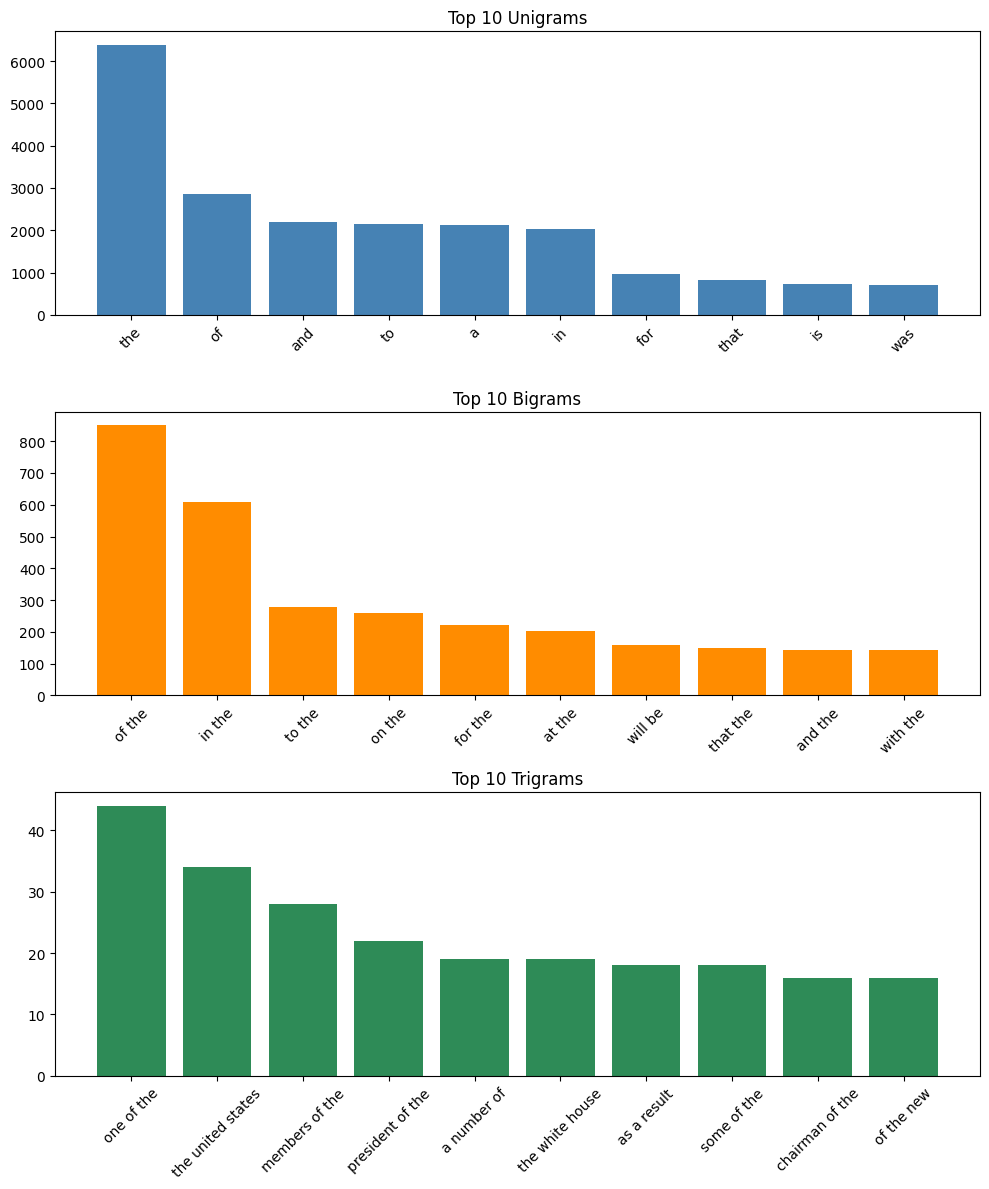

In [17]:
# Visualize the top 10 n-grams of each order
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].bar(unigram_df["Unigram"], unigram_df["Frequency"], color="steelblue")
axes[0].set_title("Top 10 Unigrams")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(bigram_df["Bigram"], bigram_df["Frequency"], color="darkorange")
axes[1].set_title("Top 10 Bigrams")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(trigram_df["Trigram"], trigram_df["Frequency"], color="seagreen")
axes[2].set_title("Top 10 Trigrams")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### (f) How does increasing N capture more contextual information?

- **Unigrams** treat each word independently and only capture overall word frequency
  (e.g. "the" is common because it's a common word in English generally) — they carry
  no information about word order or context at all.
- **Bigrams** capture immediate two-word context, revealing common short collocations
  such as *"of the"* and *"in the"* — this starts to capture local grammatical structure
  (e.g. which prepositions typically precede "the").
- **Trigrams** capture three-word sequences such as *"one of the"* and *"the united states"*,
  revealing fixed phrases and named entities that unigrams/bigrams cannot detect on their own.

As N increases, each n-gram encodes more surrounding context and can capture longer, more
specific phrases and idioms — but at the same time the number of *distinct* n-grams grows much
faster than the corpus size, so higher-order n-grams are individually rarer and the frequency
counts become increasingly sparse (the classic sparsity trade-off in N-gram language modeling).

---
## Conclusion

This notebook demonstrated:
- Sentence and word tokenization of Brown Corpus text, with lowercasing, punctuation removal, and stop-word removal.
- Stemming (Porter) vs. Lemmatization (WordNet) on a 30+ word sample, including specifically required words.
- Dictionary-based spelling correction using transposition-aware edit distance against the NLTK Words Corpus, with frequency-based tie-breaking.
- Unigram, bigram, and trigram frequency analysis on the Brown Corpus, with visualizations and a discussion of how increasing N captures more context at the cost of sparsity.